# TONTOUMA-BOT — Benchmark Traduction Français → Wolof

Compare **3 modèles NLLB** sur 4 métriques, puis sauvegarde le meilleur.

```
Texte Français
   ↓
┌─────────────────────────────────────────────────────┐
│  lahad-nllb-fr-wo  │  cibfaye-nllb-fr-wo  │  nllb  │
└─────────────────────────────────────────────────────┘
   ↓ traduction Wolof
┌──────────────────────────────────────────┐
│  BLEU  │  chrF  │  TER  │  COMET        │
└──────────────────────────────────────────┘
   ↓ score composite
🏆 Meilleur modèle → sauvegardé sur disque
```

### ⚠️ Problème identifié dans la version précédente
Les métriques BLEU/chrF/TER/COMET étaient toutes à `None` car `sacrebleu`
et `unbabel-comet` **n'étaient pas installés avant** le calcul.  
Cette version corrige ça : installation forcée en cellule 0, vérification
en cellule 1, avant tout calcul.

### Installation (cellule 0 — à exécuter en premier)


In [1]:
import subprocess, sys

paquets = [
    "sacrebleu",          # BLEU, chrF, TER
    "unbabel-comet",      # COMET
    "transformers",
    "torch",
    "pandas",
    "matplotlib",
    "sentencepiece",      # tokenizer NLLB
    "protobuf",           # requis par sentencepiece
    "pytorch-lightning<2.0", # Fixe une erreur de compatibilité avec comet (version < 2.0)
]

for p in paquets:
    print(f" Installation : {p}...")
    # For protobuf, force reinstall to fix potential version conflicts
    if p == "protobuf":
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "--force-reinstall", "-q"],
            capture_output=True, text=True
        )
    else:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True
        )

    if result.returncode == 0:
        print(f"    {p}")
    else:
        print(f"    {p} : {result.stderr[-200:]}")

print("\n Installation terminée — si tu es sur Colab, redémarre le kernel maintenant.")

 Installation : sacrebleu...
    sacrebleu
 Installation : unbabel-comet...
    unbabel-comet
 Installation : transformers...
    transformers
 Installation : torch...
    torch
 Installation : pandas...
    pandas
 Installation : matplotlib...
    matplotlib
 Installation : sentencepiece...
    sentencepiece
 Installation : protobuf...
    protobuf
 Installation : pytorch-lightning<2.0...
    pytorch-lightning<2.0

 Installation terminée — si tu es sur Colab, redémarre le kernel maintenant.


## 1. Configuration et vérification des imports

In [2]:
# ── CELLULE 1 : Imports et vérification ───────────────────────────────────
# Cette cellule VÉRIFIE que tout est bien installé avant de continuer

import time
import json
import warnings
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

warnings.filterwarnings("ignore")

# ── Vérification sacrebleu ─────────────────────────────────────────────────
try:
    import sacrebleu
    # Test rapide pour s'assurer que les fonctions sont disponibles
    _ = sacrebleu.sentence_bleu("test", ["test"]).score
    SACREBLEU_OK = True
    print(f"✅ sacrebleu {sacrebleu.__version__} — BLEU/chrF/TER disponibles")
except Exception as e:
    SACREBLEU_OK = False
    print(f"❌ sacrebleu non fonctionnel : {e}")
    print("   → Exécute la cellule 0 puis redémarre le kernel")

# ── Vérification COMET ────────────────────────────────────────────────────
try:
    from comet import download_model, load_from_checkpoint
    COMET_IMPORT_OK = True
    print("✅ unbabel-comet importé — COMET disponible")
except ImportError:
    COMET_IMPORT_OK = False
    print("⚠️  unbabel-comet non trouvé — COMET sera ignoré (les autres métriques suffisent)")

# ── Configuration ─────────────────────────────────────────────────────────
MODELES_FR_WO = {
    "lahad-nllb-fr-wo":   "Lahad/nllb200-francais-wolof",
    "cibfaye-nllb-fr-wo": "cibfaye/nllb-fr-wo",
    "nllb-general":       "facebook/nllb-200-distilled-600M",
    # "cifope-3.3B":      "cifope/nllb-fr-wol-wol-fr-3.3B",  # trop lourd
}

DEVICE              = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_IDX          = 0 if DEVICE == "cuda" else -1
RESULTS_DIR         = Path("resultats_traduction_fr_wo")
MEILLEUR_MODELE_DIR = Path("meilleur_modele_fr_wo")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"\nDevice       : {DEVICE.upper()}")
print(f"Modèles      : {list(MODELES_FR_WO.keys())}")
print(f"sacrebleu OK : {SACREBLEU_OK}")
print(f"COMET OK     : {COMET_IMPORT_OK}")

if not SACREBLEU_OK:
    raise RuntimeError("❌ sacrebleu est requis. Exécute la cellule 0 et redémarre le kernel.")


✅ sacrebleu 2.6.0 — BLEU/chrF/TER disponibles
✅ unbabel-comet importé — COMET disponible

Device       : CUDA
Modèles      : ['lahad-nllb-fr-wo', 'cibfaye-nllb-fr-wo', 'nllb-general']
sacrebleu OK : True
COMET OK     : True


## 2. Chargement des modèles

Chaque modèle est protégé par un `try/except` indépendant —
un modèle qui échoue ne bloque pas les autres.

In [3]:
# ── CELLULE 2 : Chargement des modèles ────────────────────────────────────

print("Chargement des modèles NLLB FR→WO...\n")

tokenizers           = {}
modeles              = {}
infos_modeles        = {}
echecs_chargement    = {}

for nom, chemin in MODELES_FR_WO.items():
    t0 = time.perf_counter()
    try:
        tok = AutoTokenizer.from_pretrained(chemin)
        mdl = AutoModelForSeq2SeqLM.from_pretrained(chemin).to(DEVICE)
        mdl.eval()  # mode inférence → plus rapide, pas de gradient

        temps_s  = round(time.perf_counter() - t0, 1)
        n_params = sum(p.numel() for p in mdl.parameters())

        tokenizers[nom]    = tok
        modeles[nom]       = mdl
        infos_modeles[nom] = {
            "checkpoint":         chemin,
            "n_params_M":         round(n_params / 1e6, 0),
            "temps_chargement_s": temps_s,
        }
        print(f"  ✅ {nom:25s} {n_params/1e6:.0f}M params  chargé en {temps_s}s")

    except Exception as e:
        echecs_chargement[nom] = str(e)
        print(f"  ❌ {nom:25s} ERREUR : {str(e)[:80]}")

print(f"\n{len(modeles)}/{len(MODELES_FR_WO)} modèles chargés avec succès.")
if echecs_chargement:
    print(f"Modèles en échec : {list(echecs_chargement.keys())}")


Chargement des modèles NLLB FR→WO...

  ✅ lahad-nllb-fr-wo          615M params  chargé en 17.7s
  ✅ cibfaye-nllb-fr-wo        615M params  chargé en 21.8s
  ✅ nllb-general              615M params  chargé en 9.9s

3/3 modèles chargés avec succès.


## 3. Fonction de traduction FR → WO

Les modèles sont tous de type NLLB — ils utilisent des codes de langue
normalisés (`fra_Latn` pour le français, `wol_Latn` pour le Wolof).

**Pourquoi `forced_bos_token_id` ?**  
NLLB est un modèle multilingue qui peut traduire vers 200 langues.
Sans ce paramètre, il choisirait la langue cible lui-même (souvent l'anglais).
On lui force le token de départ Wolof pour qu'il génère bien du Wolof.

In [4]:
# ── CELLULE 3 : Fonction de traduction ────────────────────────────────────

# Codes de langue NLLB
# Format : iso_Script  (iso=code pays, Script=écriture)
CODES_NLLB = {
    "fr": "fra_Latn",   # Français, alphabet latin
    "wo": "wol_Latn",   # Wolof, alphabet latin
}


def traduire(nom_modele: str, texte: str, src="fr", tgt="wo", max_new_tokens=128):
    """
    Traduit `texte` du français (src) vers le Wolof (tgt).

    Retourne : (traduction: str | None, erreur: str | None)

    Fonctionnement interne :
    1. On configure le tokenizer avec la langue source
    2. On encode le texte en tokens
    3. On génère les tokens cibles en forçant le token Wolof en début
    4. On décode les tokens cibles en texte
    """
    if nom_modele not in modeles:
        return None, f"Modèle '{nom_modele}' non chargé"

    tokenizer = tokenizers[nom_modele]
    modele    = modeles[nom_modele]

    try:
        # Étape 1 : configure la langue source
        tokenizer.src_lang = CODES_NLLB[src]

        # Étape 2 : tokenise le texte français
        inputs = tokenizer(
            texte,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(DEVICE)

        # Étape 3 : génère la traduction
        # forced_bos_token_id = premier token généré = token Wolof
        # → force le modèle à produire du Wolof et non une autre langue
        with torch.no_grad():  # pas de gradient = plus rapide
            sortie = modele.generate(
                **inputs,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(CODES_NLLB[tgt]),
                max_new_tokens=max_new_tokens,
                num_beams=4,            # beam search : explore 4 chemins en parallèle
                early_stopping=True,    # arrête si tous les beams ont fini
            )

        # Étape 4 : décode les tokens en texte
        traduction = tokenizer.batch_decode(sortie, skip_special_tokens=True)[0]
        return traduction.strip(), None

    except Exception as e:
        return None, str(e)


# Test rapide sur une phrase
print("Test rapide sur : 'Bonjour, comment allez-vous ?'\n")
for nom in list(modeles.keys())[:1]:   # teste seulement le premier pour aller vite
    trad, err = traduire(nom, "Bonjour, comment allez-vous ?")
    print(f"  {nom} → {trad or err}")

print("\n✅ Fonction de traduction prête.")


Test rapide sur : 'Bonjour, comment allez-vous ?'

  lahad-nllb-fr-wo → Sama gaa yi, naka nga def?

✅ Fonction de traduction prête.


## 4. Jeu de test annoté

10 phrases couvrant les domaines TONTOUMA-BOT : orientation,
médical, administratif, courtoisie.  
Les références Wolof sont à faire valider par un locuteur natif
pour un résultat scientifiquement rigoureux.

In [5]:
# ── CELLULE 4 : Jeu de test ───────────────────────────────────────────────

jeu_test = pd.DataFrame([
    # ── Orientation ──────────────────────────────────────────────────────
    {
        "id": "t001",
        "source_francais":  "Où se trouve le service de radiologie ?",
        "reference_wolof":  "Fan la service yi radiologie bi nekk ?",
        "domaine":          "orientation",
    },
    {
        "id": "t002",
        "source_francais":  "Comment aller aux urgences ?",
        "reference_wolof":  "Naka laay dem ci urgences yi ?",
        "domaine":          "orientation",
    },
    # ── Médical ───────────────────────────────────────────────────────────
    {
        "id": "t003",
        "source_francais":  "J'ai besoin d'un médecin car j'ai très mal au ventre.",
        "reference_wolof":  "Dama soxla doctoor ndax sama biir dafay metti lool.",
        "domaine":          "medical",
    },
    {
        "id": "t004",
        "source_francais":  "Je dois prendre ce médicament deux fois par jour.",
        "reference_wolof":  "Maa ngi wara nangu dawa bi yenaati-yoon ci bés bu nekk.",
        "domaine":          "medical",
    },
    # ── Administratif ─────────────────────────────────────────────────────
    {
        "id": "t005",
        "source_francais":  "Comment faire pour obtenir un acte de naissance ?",
        "reference_wolof":  "Naka laay def ngir am kayitu juddu ?",
        "domaine":          "administratif",
    },
    {
        "id": "t006",
        "source_francais":  "Quels documents faut-il pour renouveler sa carte d'identité ?",
        "reference_wolof":  "Ana papiye yi wara am ngir soppi sama carte d'identité ?",
        "domaine":          "administratif",
    },
    {
        "id": "t007",
        "source_francais":  "Comment prendre rendez-vous avec le spécialiste ?",
        "reference_wolof":  "Naka laay def ngir am rendez-vous ak spécialiste bi ?",
        "domaine":          "administratif",
    },
    # ── Courtoisie ────────────────────────────────────────────────────────
    {
        "id": "t008",
        "source_francais":  "Merci beaucoup pour l'aide.",
        "reference_wolof":  "Jërejëf lool ci dimbal bi.",
        "domaine":          "courtoisie",
    },
    {
        "id": "t009",
        "source_francais":  "Bonjour, je voudrais des informations sur les vaccins.",
        "reference_wolof":  "Asalaa maalekum, dama bëgg xam-xam ci vaccin yi.",
        "domaine":          "medical",
    },
    {
        "id": "t010",
        "source_francais":  "Le bureau est fermé aujourd'hui.",
        "reference_wolof":  "Biró bi mënul ubbi tey.",
        "domaine":          "orientation",
    },
])

print(f"{len(jeu_test)} phrases de test — répartition par domaine :")
print(jeu_test['domaine'].value_counts().to_string())
print()
display(jeu_test[["id", "source_francais", "reference_wolof", "domaine"]])


10 phrases de test — répartition par domaine :
domaine
orientation      3
medical          3
administratif    3
courtoisie       1



,id,source_francais,reference_wolof,domaine
0,t001,Où se trouve le service de radiologie ?,Fan la service yi radiologie bi nekk ?,orientation
1,t002,Comment aller aux urgences ?,Naka laay dem ci urgences yi ?,orientation
2,t003,J'ai besoin d'un médecin car j'ai très mal au ...,Dama soxla doctoor ndax sama biir dafay metti ...,medical
3,t004,Je dois prendre ce médicament deux fois par jour.,Maa ngi wara nangu dawa bi yenaati-yoon ci bés...,medical
4,t005,Comment faire pour obtenir un acte de naissance ?,Naka laay def ngir am kayitu juddu ?,administratif
5,t006,Quels documents faut-il pour renouveler sa car...,Ana papiye yi wara am ngir soppi sama carte d'...,administratif
6,t007,Comment prendre rendez-vous avec le spécialiste ?,Naka laay def ngir am rendez-vous ak spécialis...,administratif
7,t008,Merci beaucoup pour l'aide.,Jërejëf lool ci dimbal bi.,courtoisie
8,t009,"Bonjour, je voudrais des informations sur les ...","Asalaa maalekum, dama bëgg xam-xam ci vaccin yi.",medical
9,t010,Le bureau est fermé aujourd'hui.,Biró bi mënul ubbi tey.,orientation


## 5. Traduction de chaque phrase par chaque modèle

In [6]:
# ── CELLULE 5 : Traduction de tout le jeu de test ─────────────────────────

print(f"Traduction de {len(jeu_test)} phrases × {len(modeles)} modèles...\n")
resultats_traduction = []

for _, ligne in jeu_test.iterrows():
    for nom_modele in modeles:
        t0 = time.perf_counter()
        traduction, erreur = traduire(nom_modele, ligne["source_francais"])
        temps_ms = round((time.perf_counter() - t0) * 1000, 1)

        resultats_traduction.append({
            "id":               ligne["id"],
            "domaine":          ligne["domaine"],
            "modele":           nom_modele,
            "source_francais":  ligne["source_francais"],
            "reference_wolof":  ligne["reference_wolof"],
            "traduction":       traduction,
            "temps_ms":         temps_ms,
            "echec":            erreur is not None,
            "erreur":           erreur,
        })

    print(f"  ✅ {ligne['id']} — {ligne['source_francais'][:50]}")

df_traductions = pd.DataFrame(resultats_traduction)

print(f"\n{len(df_traductions)} lignes générées.")
nb_echecs = df_traductions['echec'].sum()
print(f"Échecs de traduction : {nb_echecs}")
print("\n=== Aperçu des traductions ===")
display(df_traductions[["id", "modele", "source_francais", "traduction", "echec"]])


Traduction de 10 phrases × 3 modèles...

  ✅ t001 — Où se trouve le service de radiologie ?
  ✅ t002 — Comment aller aux urgences ?
  ✅ t003 — J'ai besoin d'un médecin car j'ai très mal au vent
  ✅ t004 — Je dois prendre ce médicament deux fois par jour.
  ✅ t005 — Comment faire pour obtenir un acte de naissance ?
  ✅ t006 — Quels documents faut-il pour renouveler sa carte d
  ✅ t007 — Comment prendre rendez-vous avec le spécialiste ?
  ✅ t008 — Merci beaucoup pour l'aide.
  ✅ t009 — Bonjour, je voudrais des informations sur les vacc
  ✅ t010 — Le bureau est fermé aujourd'hui.

30 lignes générées.
Échecs de traduction : 0

=== Aperçu des traductions ===


,id,modele,source_francais,traduction,echec
0,t001,lahad-nllb-fr-wo,Où se trouve le service de radiologie ?,Fan la Radiologie bi nekk ?,False
1,t001,cibfaye-nllb-fr-wo,Où se trouve le service de radiologie ?,Fan la bérébu ràññew bi nekk?,False
2,t001,nllb-general,Où se trouve le service de radiologie ?,Foofa taxawu radioloji bi nekk?,False
3,t002,lahad-nllb-fr-wo,Comment aller aux urgences ?,naka ngay def ngir dem ci E.R.?,False
4,t002,cibfaye-nllb-fr-wo,Comment aller aux urgences ?,Naka lañu war a dem ci bërëbu jamp yi?,False
5,t002,nllb-general,Comment aller aux urgences ?,Naka la mën a dugal ci àjjana bi?,False
6,t003,lahad-nllb-fr-wo,J'ai besoin d'un médecin car j'ai très mal au ...,Dama soxla doktër ndax sama biir dafay metti l...,False
7,t003,cibfaye-nllb-fr-wo,J'ai besoin d'un médecin car j'ai très mal au ...,Ma soxla fajkat ndax sama biir dafa metti lool.,False
8,t003,nllb-general,J'ai besoin d'un médecin car j'ai très mal au ...,"Ma soxla doktoor, ndaxte sama biir dafa metti ...",False
9,t004,lahad-nllb-fr-wo,Je dois prendre ce médicament deux fois par jour.,Dama wara jël drog bii ñaari yoon ci bis bi.,False


## 6. Calcul des métriques BLEU, chrF, TER

| Métrique | Ce qu'elle mesure | Interprétation | Pourquoi pour le Wolof |
|---|---|---|---|
| **BLEU** | N-grammes de mots communs | ↑ élevé = mieux | Standard international, comparaison avec la littérature |
| **chrF** | N-grammes de **caractères** | ↑ élevé = mieux | **Recommandé pour le Wolof** : robuste aux variations morphologiques |
| **TER** | Nb d'opérations pour corriger | ↓ faible = mieux | Mesure l'effort de correction humaine |

**Pourquoi chrF est préférable à BLEU pour le Wolof :**  
Le Wolof agglutine les mots (`jëfandikukat` = utilisateur).  
Une légère variation de suffixe fait tomber BLEU à 0, mais chrF  
voit que 90% des caractères sont corrects.

In [7]:
# ── CELLULE 6 : BLEU / chrF / TER ─────────────────────────────────────────

# sacrebleu est vérifié en cellule 1 — on peut utiliser directement
import sacrebleu


def calculer_bleu_chrf_ter(traduction: str, reference: str) -> dict:
    """
    Calcule les 3 métriques pour une paire (traduction, référence).

    sentence_bleu  → BLEU au niveau phrase (0-100)
    sentence_chrf  → chrF au niveau phrase (0-100)
    sentence_ter   → TER au niveau phrase  (0 à +inf, plus bas = mieux)

    Retourne None si la traduction est vide (modèle en échec).
    """
    if not traduction or pd.isna(traduction):
        return {"bleu": None, "chrf": None, "ter": None}

    return {
        "bleu": round(sacrebleu.sentence_bleu(traduction, [reference]).score, 2),
        "chrf": round(sacrebleu.sentence_chrf(traduction, [reference]).score, 2),
        "ter":  round(sacrebleu.sentence_ter(traduction,  [reference]).score, 2),
    }


# Application ligne par ligne
print("Calcul BLEU / chrF / TER sur toutes les traductions...")
metriques_df = df_traductions.apply(
    lambda row: calculer_bleu_chrf_ter(row["traduction"], row["reference_wolof"]),
    axis=1,
)
df_metriques  = pd.DataFrame(list(metriques_df))
df_traductions = pd.concat([df_traductions, df_metriques], axis=1)

print("\n=== Résultats détaillés phrase par phrase ===")
display(df_traductions[[
    "id", "modele", "source_francais",
    "reference_wolof", "traduction",
    "bleu", "chrf", "ter", "temps_ms"
]])

# Résumé moyen par modèle
print("\n=== Moyenne par modèle ===")
resume_partiel = df_traductions.groupby("modele")[["bleu", "chrf", "ter", "temps_ms"]].mean().round(2)
display(resume_partiel)


Calcul BLEU / chrF / TER sur toutes les traductions...

=== Résultats détaillés phrase par phrase ===


,id,modele,source_francais,reference_wolof,traduction,bleu,chrf,ter,temps_ms
0,t001,lahad-nllb-fr-wo,Où se trouve le service de radiologie ?,Fan la service yi radiologie bi nekk ?,Fan la Radiologie bi nekk ?,27.22,59.35,25.00,197.5
1,t001,cibfaye-nllb-fr-wo,Où se trouve le service de radiologie ?,Fan la service yi radiologie bi nekk ?,Fan la bérébu ràññew bi nekk?,26.65,26.82,62.50,275.5
2,t001,nllb-general,Où se trouve le service de radiologie ?,Fan la service yi radiologie bi nekk ?,Foofa taxawu radioloji bi nekk?,21.65,34.06,87.50,350.4
3,t002,lahad-nllb-fr-wo,Comment aller aux urgences ?,Naka laay dem ci urgences yi ?,naka ngay def ngir dem ci E.R.?,8.30,24.45,71.43,344.8
4,t002,cibfaye-nllb-fr-wo,Comment aller aux urgences ?,Naka laay dem ci urgences yi ?,Naka lañu war a dem ci bërëbu jamp yi?,12.55,31.50,85.71,373.5
5,t002,nllb-general,Comment aller aux urgences ?,Naka laay dem ci urgences yi ?,Naka la mën a dugal ci àjjana bi?,6.27,23.72,100.00,346.8
6,t003,lahad-nllb-fr-wo,J'ai besoin d'un médecin car j'ai très mal au ...,Dama soxla doctoor ndax sama biir dafay metti ...,Dama soxla doktër ndax sama biir dafay metti l...,70.71,84.55,11.11,370.3
7,t003,cibfaye-nllb-fr-wo,J'ai besoin d'un médecin car j'ai très mal au ...,Dama soxla doctoor ndax sama biir dafay metti ...,Ma soxla fajkat ndax sama biir dafa metti lool.,27.30,62.47,33.33,388.4
8,t003,nllb-general,J'ai besoin d'un médecin car j'ai très mal au ...,Dama soxla doctoor ndax sama biir dafay metti ...,"Ma soxla doktoor, ndaxte sama biir dafa metti ...",18.36,63.46,44.44,423.2
9,t004,lahad-nllb-fr-wo,Je dois prendre ce médicament deux fois par jour.,Maa ngi wara nangu dawa bi yenaati-yoon ci bés...,Dama wara jël drog bii ñaari yoon ci bis bi.,4.84,22.35,90.91,316.2



=== Moyenne par modèle ===


,bleu,chrf,ter,temps_ms
modele,,,,
cibfaye-nllb-fr-wo,12.56,31.88,81.68,358.08
lahad-nllb-fr-wo,19.27,38.22,65.69,312.44
nllb-general,12.03,32.06,95.04,356.13


## 7. Calcul de la métrique COMET

COMET est une métrique **neuronale** : elle compare le sens sémantique
des traductions au lieu de simplement compter les mots communs.

**⚠️ Limite importante pour le Wolof :**  
Les modèles COMET ont été entraînés principalement sur des langues
à hautes ressources. Le score COMET est donc **indicatif** pour le Wolof —
chrF reste la métrique principale.

## 8. Tableau récapitulatif et résumé par modèle

In [8]:
# ── CELLULE 8 : Résumé agrégé ─────────────────────────────────────────────

# Colonnes disponibles selon ce qui a pu être calculé
colonnes_metriques = [c for c in ["bleu", "chrf", "ter", "comet", "temps_ms"]
                      if c in df_traductions.columns
                      and df_traductions[c].notna().any()]

df_resume = df_traductions.groupby("modele")[colonnes_metriques].mean(numeric_only=True).round(3)
df_resume["taux_echec"] = df_traductions.groupby("modele")["echec"].mean().round(3)
df_resume["nb_params_M"] = df_resume.index.map(
    lambda n: infos_modeles.get(n, {}).get("n_params_M", None)
)

# Sauvegarde CSV
chemin_detail  = RESULTS_DIR / "resultats_detailles.csv"
chemin_resume  = RESULTS_DIR / "resume_par_modele.csv"
df_traductions.to_csv(chemin_detail, index=False)
df_resume.to_csv(chemin_resume)

print(f"✅ Résultats détaillés : {chemin_detail}")
print(f"✅ Résumé             : {chemin_resume}")

print("\n=== RÉSUMÉ PAR MODÈLE ===")
print("(BLEU/chrF/COMET : ↑ élevé = mieux | TER : ↓ faible = mieux)\n")
display(df_resume)


✅ Résultats détaillés : resultats_traduction_fr_wo/resultats_detailles.csv
✅ Résumé             : resultats_traduction_fr_wo/resume_par_modele.csv

=== RÉSUMÉ PAR MODÈLE ===
(BLEU/chrF/COMET : ↑ élevé = mieux | TER : ↓ faible = mieux)



,bleu,chrf,ter,temps_ms,taux_echec,nb_params_M
modele,,,,,,
cibfaye-nllb-fr-wo,12.565,31.882,81.677,358.08,0.0,615.0
lahad-nllb-fr-wo,19.269,38.223,65.686,312.44,0.0,615.0
nllb-general,12.030,32.062,95.035,356.13,0.0,615.0


## 9. Graphiques comparatifs

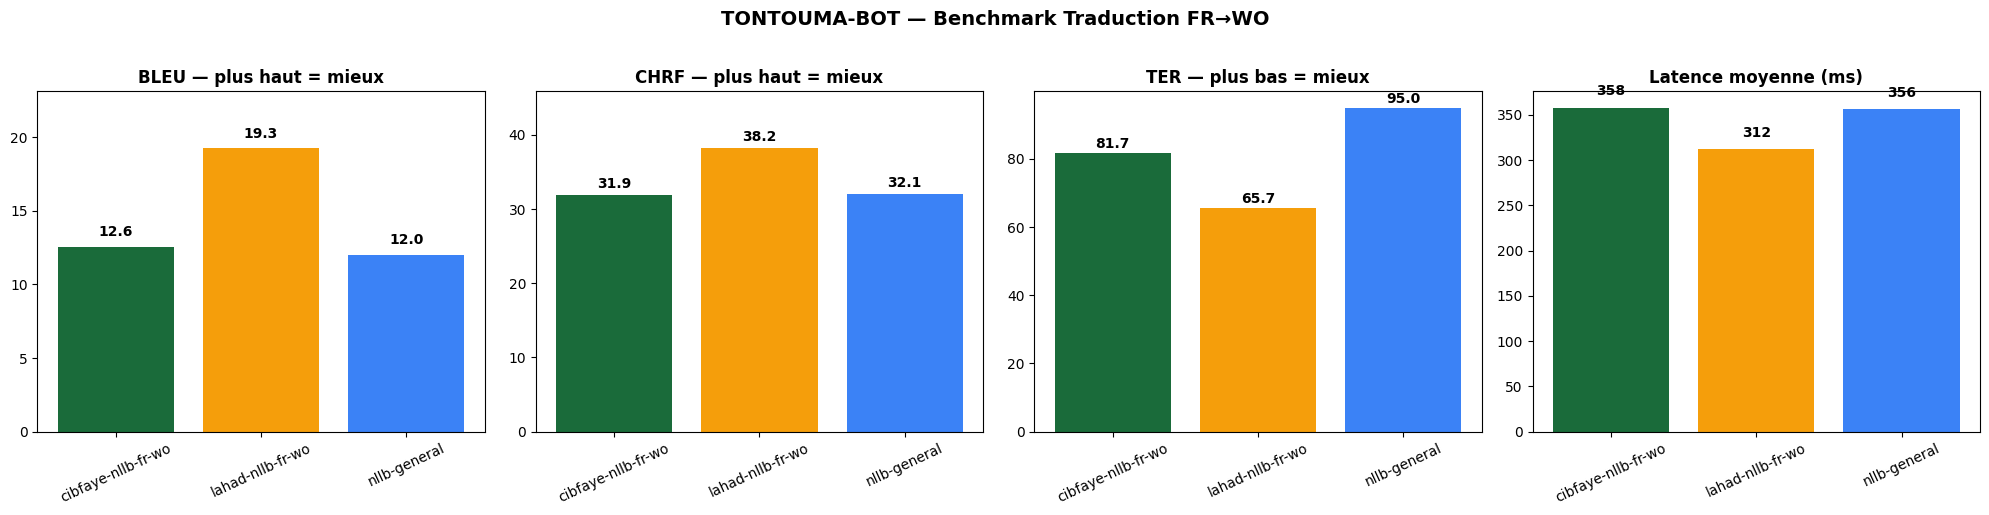

✅ Graphiques sauvegardés : resultats_traduction_fr_wo/graphiques_benchmark.png


In [9]:
# ── CELLULE 9 : Visualisation ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COULEURS = ["#1a6b3a", "#f59e0b", "#3b82f6", "#ef4444"]
modeles_labels = df_resume.index.tolist()

# Colonnes à tracer
metriques_hautes = [c for c in ["bleu", "chrf", "comet"] if c in df_resume and df_resume[c].notna().any()]
has_ter          = "ter"     in df_resume and df_resume["ter"].notna().any()
has_latence      = "temps_ms" in df_resume and df_resume["temps_ms"].notna().any()

n_cols = len(metriques_hautes) + int(has_ter) + int(has_latence)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

ax_idx = 0

# Métriques "plus haut = mieux"
for metrique in metriques_hautes:
    vals = df_resume[metrique].values
    barres = axes[ax_idx].bar(modeles_labels, vals, color=COULEURS[:len(modeles_labels)])
    axes[ax_idx].set_title(f"{metrique.upper()} — plus haut = mieux", fontweight="bold")
    axes[ax_idx].tick_params(axis="x", rotation=25)
    axes[ax_idx].set_ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
    # Étiquettes valeurs
    for b, v in zip(barres, vals):
        if not np.isnan(v):
            axes[ax_idx].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                              f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax_idx += 1

# TER (plus bas = mieux)
if has_ter:
    vals = df_resume["ter"].values
    barres = axes[ax_idx].bar(modeles_labels, vals, color=COULEURS[:len(modeles_labels)])
    axes[ax_idx].set_title("TER — plus bas = mieux", fontweight="bold")
    axes[ax_idx].tick_params(axis="x", rotation=25)
    for b, v in zip(barres, vals):
        if not np.isnan(v):
            axes[ax_idx].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                              f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax_idx += 1

# Latence
if has_latence:
    vals = df_resume["temps_ms"].values
    barres = axes[ax_idx].bar(modeles_labels, vals, color=COULEURS[:len(modeles_labels)])
    axes[ax_idx].set_title("Latence moyenne (ms)", fontweight="bold")
    axes[ax_idx].tick_params(axis="x", rotation=25)
    for b, v in zip(barres, vals):
        axes[ax_idx].text(b.get_x() + b.get_width()/2, b.get_height() + 10,
                          f"{v:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("TONTOUMA-BOT — Benchmark Traduction FR→WO", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "graphiques_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Graphiques sauvegardés : {RESULTS_DIR/'graphiques_benchmark.png'}")


## 10. Score composite et sélection du meilleur modèle

Le score composite est une **moyenne pondérée normalisée** des métriques :

| Métrique | Poids | Raison |
|---|---|---|
| chrF | 35% | Métrique principale pour le Wolof (morphologie riche) |
| BLEU | 25% | Standard de comparaison avec la littérature |
| COMET | 25% | Sens sémantique (si disponible) |
| TER | 15% | Effort de correction (inversé) |

La **normalisation** ramène chaque métrique entre 0 et 1,
pour que chrF (0-100) et COMET (0-1) aient le même poids réel.

In [10]:
# ── CELLULE 10 : Score composite ──────────────────────────────────────────

def normaliser(serie: pd.Series, inverser: bool = False) -> pd.Series:
    """
    Normalise une série entre 0 et 1 (min-max).
    inverser=True pour les métriques où plus bas = mieux (TER).

    Exemple :
      série = [30, 50, 80]  →  [0.0, 0.4, 1.0]
      inversée              →  [1.0, 0.6, 0.0]
    """
    s = serie.dropna()
    if s.empty or s.max() == s.min():
        # Tous identiques → score neutre 0.5
        return pd.Series(0.5, index=serie.index)
    norm = (serie - s.min()) / (s.max() - s.min())
    return (1 - norm) if inverser else norm


# Composantes et poids selon disponibilité
composantes = []
if "chrf"  in df_resume and df_resume["chrf"].notna().any():  composantes.append(("chrf",  0.35, False))
if "bleu"  in df_resume and df_resume["bleu"].notna().any():  composantes.append(("bleu",  0.25, False))
if "comet" in df_resume and df_resume["comet"].notna().any(): composantes.append(("comet", 0.25, False))
if "ter"   in df_resume and df_resume["ter"].notna().any():   composantes.append(("ter",   0.15, True))

poids_total = sum(p for _, p, _ in composantes)
score = pd.Series(0.0, index=df_resume.index)

print("Composantes du score composite :")
for nom_metrique, poids, inv in composantes:
    contribution = (poids / poids_total) * normaliser(df_resume[nom_metrique], inverser=inv)
    score += contribution
    print(f"  {nom_metrique:8s}  poids={poids:.0%}  {'(inversé)' if inv else ''}")

df_resume["score_composite"] = score.round(4)

print("\n=== CLASSEMENT FINAL ===")
colonnes_affichage = ["score_composite"] + [m for m, _, _ in composantes] + ["temps_ms"]
display(
    df_resume[colonnes_affichage]
    .sort_values("score_composite", ascending=False)
    .style.highlight_max(subset=["score_composite", "bleu", "chrf"] if "bleu" in df_resume else ["score_composite", "chrf"], color="#bbf7d0")
          .highlight_min(subset=["ter"] if "ter" in df_resume else [], color="#bbf7d0")
)

# Sélection du gagnant
candidats    = df_resume[df_resume.index.isin(modeles.keys())]
nom_meilleur = candidats["score_composite"].idxmax()
score_max    = candidats.loc[nom_meilleur, "score_composite"]

print(f"\n🏆 MEILLEUR MODÈLE : {nom_meilleur}")
print(f"   Score composite : {score_max:.4f}")
if "chrf" in df_resume:
    print(f"   chrF moyen      : {df_resume.loc[nom_meilleur, 'chrf']:.2f}")
if "bleu" in df_resume:
    print(f"   BLEU moyen      : {df_resume.loc[nom_meilleur, 'bleu']:.2f}")
if "ter" in df_resume:
    print(f"   TER moyen       : {df_resume.loc[nom_meilleur, 'ter']:.2f}")
print(f"   Latence moyenne : {df_resume.loc[nom_meilleur, 'temps_ms']:.0f} ms")


Composantes du score composite :
  chrf      poids=35%  
  bleu      poids=25%  
  ter       poids=15%  (inversé)

=== CLASSEMENT FINAL ===


,score_composite,chrf,bleu,ter,temps_ms
modele,,,,,
lahad-nllb-fr-wo,1.000000,38.223000,19.269000,65.686000,312.440000
cibfaye-nllb-fr-wo,0.115700,31.882000,12.565000,81.677000,358.080000
nllb-general,0.013200,32.062000,12.030000,95.035000,356.130000



🏆 MEILLEUR MODÈLE : lahad-nllb-fr-wo
   Score composite : 1.0000
   chrF moyen      : 38.22
   BLEU moyen      : 19.27
   TER moyen       : 65.69
   Latence moyenne : 312 ms


## 11. Meilleur modèle par métrique individuelle

Un modèle peut dominer une métrique mais pas une autre.  
Cette cellule affiche le gagnant pour chaque critère séparément.

In [11]:
# ── CELLULE 11 : Podium par métrique ──────────────────────────────────────

print("=" * 55)
print("MEILLEUR MODÈLE PAR MÉTRIQUE INDIVIDUELLE")
print("=" * 55)

if "bleu" in df_resume and df_resume["bleu"].notna().any():
    gagnant = df_resume["bleu"].idxmax()
    print(f"\n🏆 BLEU  (↑ mieux) : {gagnant}")
    for m, v in df_resume["bleu"].sort_values(ascending=False).items():
        flag = " ← 🏆" if m == gagnant else ""
        print(f"   {m:30s} {v:.2f}{flag}")

if "chrf" in df_resume and df_resume["chrf"].notna().any():
    gagnant = df_resume["chrf"].idxmax()
    print(f"\n🏆 chrF  (↑ mieux) : {gagnant}  ← MÉTRIQUE PRINCIPALE WOLOF")
    for m, v in df_resume["chrf"].sort_values(ascending=False).items():
        flag = " ← 🏆" if m == gagnant else ""
        print(f"   {m:30s} {v:.2f}{flag}")

if "ter" in df_resume and df_resume["ter"].notna().any():
    gagnant = df_resume["ter"].idxmin()
    print(f"\n🏆 TER   (↓ mieux) : {gagnant}")
    for m, v in df_resume["ter"].sort_values(ascending=True).items():
        flag = " ← 🏆" if m == gagnant else ""
        print(f"   {m:30s} {v:.2f}{flag}")

if "comet" in df_resume and df_resume["comet"].notna().any():
    gagnant = df_resume["comet"].idxmax()
    print(f"\n🏆 COMET (↑ mieux) : {gagnant}")
    for m, v in df_resume["comet"].sort_values(ascending=False).items():
        flag = " ← 🏆" if m == gagnant else ""
        print(f"   {m:30s} {v:.4f}{flag}")

gagnant_vitesse = df_resume["temps_ms"].idxmin()
print(f"\n⚡ Latence (↓ mieux) : {gagnant_vitesse}")
for m, v in df_resume["temps_ms"].sort_values().items():
    flag = " ← ⚡" if m == gagnant_vitesse else ""
    print(f"   {m:30s} {v:.0f} ms{flag}")

print(f"\n{'='*55}")
print(f"🎯 CHOIX FINAL (score composite) : {nom_meilleur}")
print(f"{'='*55}")


MEILLEUR MODÈLE PAR MÉTRIQUE INDIVIDUELLE

🏆 BLEU  (↑ mieux) : lahad-nllb-fr-wo
   lahad-nllb-fr-wo               19.27 ← 🏆
   cibfaye-nllb-fr-wo             12.56
   nllb-general                   12.03

🏆 chrF  (↑ mieux) : lahad-nllb-fr-wo  ← MÉTRIQUE PRINCIPALE WOLOF
   lahad-nllb-fr-wo               38.22 ← 🏆
   nllb-general                   32.06
   cibfaye-nllb-fr-wo             31.88

🏆 TER   (↓ mieux) : lahad-nllb-fr-wo
   lahad-nllb-fr-wo               65.69 ← 🏆
   cibfaye-nllb-fr-wo             81.68
   nllb-general                   95.03

⚡ Latence (↓ mieux) : lahad-nllb-fr-wo
   lahad-nllb-fr-wo               312 ms ← ⚡
   nllb-general                   356 ms
   cibfaye-nllb-fr-wo             358 ms

🎯 CHOIX FINAL (score composite) : lahad-nllb-fr-wo


## 12. Sauvegarde du meilleur modèle sur disque

Le meilleur modèle est sauvegardé localement avec `save_pretrained()`.
Ainsi, la prochaine session peut le recharger directement,
sans redépendre du HuggingFace Hub ni de la connexion réseau.

```
meilleur_modele_fr_wo/
├── config.json             ← architecture du modèle
├── model.safetensors       ← poids du modèle (~1.2 GB)
├── tokenizer.json          ← vocabulaire
├── tokenizer_config.json   ← configuration du tokenizer
├── generation_config.json  ← paramètres de génération
└── fiche_selection.json    ← traçabilité : scores + date
```

In [12]:
# ── CELLULE 12 : Sauvegarde sur disque ────────────────────────────────────

MEILLEUR_MODELE_DIR.mkdir(exist_ok=True)

print(f" Sauvegarde de '{nom_meilleur}' vers {MEILLEUR_MODELE_DIR}/...")
tokenizers[nom_meilleur].save_pretrained(MEILLEUR_MODELE_DIR)
modeles[nom_meilleur].save_pretrained(MEILLEUR_MODELE_DIR)

# Fiche de traçabilité
fiche = {
    "nom_cle":           nom_meilleur,
    "checkpoint_source": MODELES_FR_WO[nom_meilleur],
    "score_composite":   float(df_resume.loc[nom_meilleur, "score_composite"]),
    "bleu":  float(df_resume.loc[nom_meilleur, "bleu"])  if "bleu"  in df_resume and pd.notna(df_resume.loc[nom_meilleur, "bleu"])  else None,
    "chrf":  float(df_resume.loc[nom_meilleur, "chrf"])  if "chrf"  in df_resume and pd.notna(df_resume.loc[nom_meilleur, "chrf"])  else None,
    "ter":   float(df_resume.loc[nom_meilleur, "ter"])   if "ter"   in df_resume and pd.notna(df_resume.loc[nom_meilleur, "ter"])   else None,
    "comet": float(df_resume.loc[nom_meilleur, "comet"]) if "comet" in df_resume and pd.notna(df_resume.loc[nom_meilleur, "comet"]) else None,
    "latence_ms_moyenne": float(df_resume.loc[nom_meilleur, "temps_ms"]),
    "date_benchmark":    pd.Timestamp.now().isoformat(),
    "nb_phrases_test":   len(jeu_test),
    "device":            DEVICE,
}
with open(MEILLEUR_MODELE_DIR / "fiche_selection.json", "w", encoding="utf-8") as f:
    json.dump(fiche, f, ensure_ascii=False, indent=2)

print(f"\n✅ Modèle sauvegardé dans : {MEILLEUR_MODELE_DIR}/")
print("\nFichiers présents :")
for f in sorted(MEILLEUR_MODELE_DIR.glob("*")):
    taille_mb = f.stat().st_size / 1e6
    print(f"  - {f.name:40s} {taille_mb:.1f} MB")

print(f"""
─────────────────────────────────────────────────────
Pour recharger le modèle la prochaine session :

  from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
  tokenizer = AutoTokenizer.from_pretrained("{MEILLEUR_MODELE_DIR}")
  modele    = AutoModelForSeq2SeqLM.from_pretrained("{MEILLEUR_MODELE_DIR}")

Pour le pusher sur HuggingFace Hub :
  modele.push_to_hub("awafaye16/tontouma-fr-wo")
  tokenizer.push_to_hub("awafaye16/tontouma-fr-wo")
─────────────────────────────────────────────────────
""")


 Sauvegarde de 'lahad-nllb-fr-wo' vers meilleur_modele_fr_wo/...

✅ Modèle sauvegardé dans : meilleur_modele_fr_wo/

Fichiers présents :
  - config.json                              0.0 MB
  - fiche_selection.json                     0.0 MB
  - generation_config.json                   0.0 MB
  - model.safetensors                        2460.4 MB
  - sentencepiece.bpe.model                  4.9 MB
  - special_tokens_map.json                  0.0 MB
  - tokenizer.json                           32.2 MB
  - tokenizer_config.json                    0.0 MB

─────────────────────────────────────────────────────
Pour recharger le modèle la prochaine session :

  from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
  tokenizer = AutoTokenizer.from_pretrained("meilleur_modele_fr_wo")
  modele    = AutoModelForSeq2SeqLM.from_pretrained("meilleur_modele_fr_wo")

Pour le pusher sur HuggingFace Hub :
  modele.push_to_hub("awafaye16/tontouma-fr-wo")
  tokenizer.push_to_hub("awafaye16/tontoum

In [20]:
# Pour le pusher sur HuggingFace Hub :
# Récupérer le meilleur modèle et son tokenizer
modele = modeles[nom_meilleur]
tokenizer = tokenizers[nom_meilleur]

from huggingface_hub import notebook_login

notebook_login()

modele.push_to_hub("EvaF28/T-bot_fr_wo1")
tokenizer.push_to_hub("EvaF28/T-bot_fr_wo1")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._q594or/model.safetensors:   0%|          | 27.0kB / 2.46GB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...x/sentencepiece.bpe.model: 100%|##########| 4.85MB / 4.85MB            

  ...mps_xvix0x/tokenizer.json: 100%|#########9| 32.1MB / 32.2MB            

CommitInfo(commit_url='https://huggingface.co/EvaF28/T-bot_fr_wo1/commit/19ec29a22c64f9fbceb92e234a189b5d2de3251b', commit_message='Upload tokenizer', commit_description='', oid='19ec29a22c64f9fbceb92e234a189b5d2de3251b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/EvaF28/T-bot_fr_wo1', endpoint='https://huggingface.co', repo_type='model', repo_id='EvaF28/T-bot_fr_wo1'), pr_revision=None, pr_num=None)

Le modèle est désormais en ligne et accessible publiquement à l'adresse suivante : https://huggingface.co/EvaF28/T-bot_fr_wo1

from transformers import AutoModelForCausalLM, AutoTokenizer

repo_id = "EvaF28/T-bot_fr_wo1"

tokenizer = AutoTokenizer.from_pretrained(repo_id)
modele = AutoModelForCausalLM.from_pretrained(repo_id)